In [92]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import torch

from prism.config import PROCESSED_DATA_DIR, MODELS_DIR
from prism.legacy import normalise, modelStats
from prism.maskedmlp import train_mlp_batched, mlpmask_pytorch
from prism.save_models import save_mlp
from prism.partial_responses import partial_responses
from prism.nomogram import nomogram
from prism.lasso import lasso
from prism.device_tools import get_device, print_tensor_info

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [93]:
%reload_ext autoreload

## Set computation device and parameters

In [94]:
# By default, assign device according to CUDA > MPS > CPU
device = get_device()
print(f"Using device: {device}")

Using device: cuda


In [95]:
# Optionally, overwrite the default device to CPU
# device = 'cpu'
# print(f"Using device: {device}")

In [96]:
# Parameters
method = 'lebesgue'
SAVE_MODELS = False

seed = 257
np.random.seed(seed)
torch.manual_seed(seed)

## Load and preprocess data

In [97]:
data_train = pd.read_csv(PROCESSED_DATA_DIR.joinpath('imputed_dataset1_train.csv'))
data_test = pd.read_csv(PROCESSED_DATA_DIR.joinpath('imputed_dataset1_test.csv'))
data_val = pd.read_csv(PROCESSED_DATA_DIR.joinpath('imputed_dataset1_val.csv'))

data_train_test = pd.concat([data_train,data_test]) # used for axis annotation in some plotting functions

# drop id column
data_train.drop('trr_id_code',axis=1,inplace=True)
data_test.drop('trr_id_code',axis=1,inplace=True)
data_val.drop('trr_id_code',axis=1,inplace=True)

target_col = 'oneyearmort'

x_train0 = data_train.drop(target_col,axis=1)
y_train = data_train[target_col]

x_test0 = data_test.drop(target_col,axis=1)
y_test = data_test[target_col]

x_val0 = data_val.drop(target_col,axis=1)
y_val = data_val[target_col]

[x_train,x_test] = normalise(x_train0,x_test0)
x_val = normalise(x_val0)

x_train_tensor = torch.tensor(x_train.values, dtype=torch.float32, device=device)
x_test_tensor = torch.tensor(x_test.values, dtype=torch.float32, device=device)
x_val_tensor = torch.tensor(x_val.values, dtype=torch.float32, device=device)

x_train0_median = x_train0.median().values
x_train0_std = x_train0.std().values

In [98]:
feature_names = [
    'don age',
    'don isch time min',
    'rec age yr',
    'rec creat',
    'rec infect 2wk',
    'rec vent',
    'rec sex',
    'tx year',
    'ICM',
    'NICM',
    'prior tx'
]

## Train MLP

In [99]:
mlp_params = {
    'n_hidden': 10,
    'weight_decay': 1e-5,
    'lr': 0.001,
    'patience': 50,
    'tolerance': 0.0001,
    'batch_size': 1024,
    'device': device,
    'seed': seed
}

mlp = train_mlp_batched(x_train, y_train, x_test, y_test, **mlp_params)

Epoch 0: Train loss 0.6690, Val loss 0.6166
Epoch 1: Train loss 0.5749, Val loss 0.5303
Epoch 2: Train loss 0.5062, Val loss 0.4680
Epoch 3: Train loss 0.4573, Val loss 0.4224
Epoch 4: Train loss 0.4240, Val loss 0.3906
Epoch 5: Train loss 0.4014, Val loss 0.3693
Epoch 6: Train loss 0.3869, Val loss 0.3563
Epoch 7: Train loss 0.3782, Val loss 0.3485
Epoch 8: Train loss 0.3726, Val loss 0.3440
Epoch 9: Train loss 0.3694, Val loss 0.3416
Epoch 10: Train loss 0.3667, Val loss 0.3402
Epoch 11: Train loss 0.3653, Val loss 0.3395
Epoch 12: Train loss 0.3644, Val loss 0.3393
Epoch 13: Train loss 0.3640, Val loss 0.3392
Epoch 14: Train loss 0.3631, Val loss 0.3391
Epoch 15: Train loss 0.3621, Val loss 0.3391
Epoch 16: Train loss 0.3624, Val loss 0.3392
Epoch 17: Train loss 0.3617, Val loss 0.3392
Epoch 18: Train loss 0.3613, Val loss 0.3393
Epoch 19: Train loss 0.3611, Val loss 0.3392
Epoch 20: Train loss 0.3611, Val loss 0.3393
Epoch 21: Train loss 0.3608, Val loss 0.3394
Epoch 22: Train loss

# Evaluate MLP

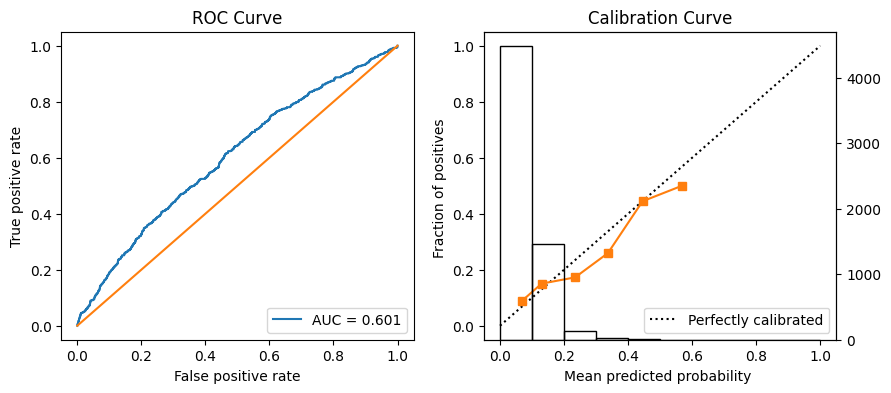


-------- Metrics --------
prevalence: 0.123
sensitivity: 0.241
specificity: 0.864
accuracy: 0.797
ppv: 0.175
auc score: 0.601
auc lower ci: 0.577
auc upper ci: 0.623
-------------------------


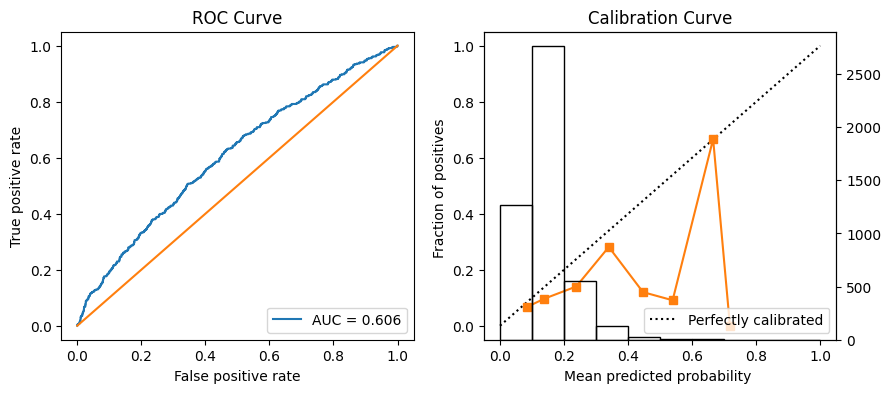


-------- Metrics --------
prevalence: 0.123
sensitivity: 0.667
specificity: 0.489
accuracy: 0.507
ppv: 0.126
auc score: 0.606
auc lower ci: 0.582
auc upper ci: 0.631
-------------------------


In [100]:
y_test_blackbox = mlp.predict(x_test_tensor).cpu().numpy()
y_val_blackbox = mlp.predict(x_val_tensor).cpu().numpy()

mlp_metrics_test = modelStats(y_test_blackbox, y_test, y_train, ROC=True, mdlCalibration=True, metricNames=True, auc_ci=True)
modelStats(y_val_blackbox, y_val, y_train, ROC=True, mdlCalibration=True, metricNames=True, auc_ci=True);

In [101]:
# Save MLP
if SAVE_MODELS:
    save_mlp(mlp, mlp_params, mlp_metrics_test, MODELS_DIR)


# MLP LASSO

In [102]:
%reload_ext autoreload
# by default, max_workers (threads) = logical CPU cores - 1. Otherwise, set optional argument max_workers
# for single GPU (cuda): choose max_workers=1.
# for MPS (Apple Silicon): start with max_workers=1, then experiment with more 
partial_responses_params = {
    'x_train' : x_train_tensor,
    'method' : method,
    'device' : device,
    'batch_size' : 512,
    'max_workers' : 1
}

partial_responses_train = partial_responses(x_train_tensor, mlp, **partial_responses_params)

partial_responses_test = partial_responses(x_test_tensor, mlp,  **partial_responses_params)

Main compute device: cuda
Max threads: 1
Batch size: 512
Univariate 0,	(cuda)
Univariate 1,	(cuda)
Univariate 2,	(cuda)
Univariate 3,	(cuda)
Univariate 4,	(cuda)
Univariate 5,	(cuda)
Univariate 6,	(cuda)
Univariate 7,	(cuda)
Univariate 8,	(cuda)
Univariate 9,	(cuda)
Univariate 10,	(cuda)
Bivariate 0,1,	(cuda)
Bivariate 0,2,	(cuda)
Bivariate 0,3,	(cuda)
Bivariate 0,4,	(cuda)
Bivariate 0,5,	(cuda)
Bivariate 0,6,	(cuda)
Bivariate 0,7,	(cuda)
Bivariate 0,8,	(cuda)
Bivariate 0,9,	(cuda)
Bivariate 0,10,	(cuda)
Bivariate 1,2,	(cuda)
Bivariate 1,3,	(cuda)
Bivariate 1,4,	(cuda)
Bivariate 1,5,	(cuda)
Bivariate 1,6,	(cuda)
Bivariate 1,7,	(cuda)
Bivariate 1,8,	(cuda)
Bivariate 1,9,	(cuda)
Bivariate 1,10,	(cuda)
Bivariate 2,3,	(cuda)
Bivariate 2,4,	(cuda)
Bivariate 2,5,	(cuda)
Bivariate 2,6,	(cuda)
Bivariate 2,7,	(cuda)
Bivariate 2,8,	(cuda)
Bivariate 2,9,	(cuda)
Bivariate 2,10,	(cuda)
Bivariate 3,4,	(cuda)
Bivariate 3,5,	(cuda)
Bivariate 3,6,	(cuda)
Bivariate 3,7,	(cuda)
Bivariate 3,8,	(cuda)
Biva

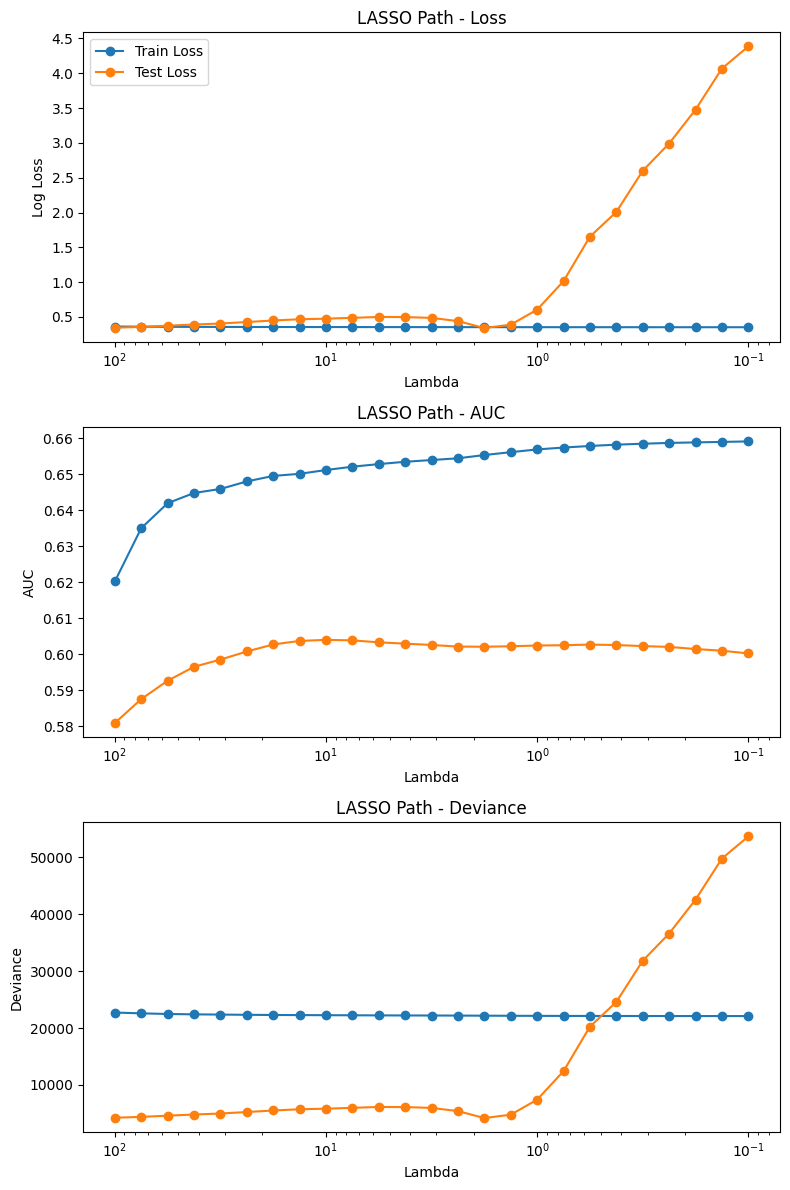

All fits converged successfully.


In [103]:
%reload_ext autoreload
lasso_results = lasso(
    partial_responses_train, 
    partial_responses_test, 
    y_train, 
    y_test, 
    feature_names=feature_names,
    nlambda=25, 
    min_lambda=0.1,
    max_lambda=100,
    batch_size=2,
    seed=seed
)

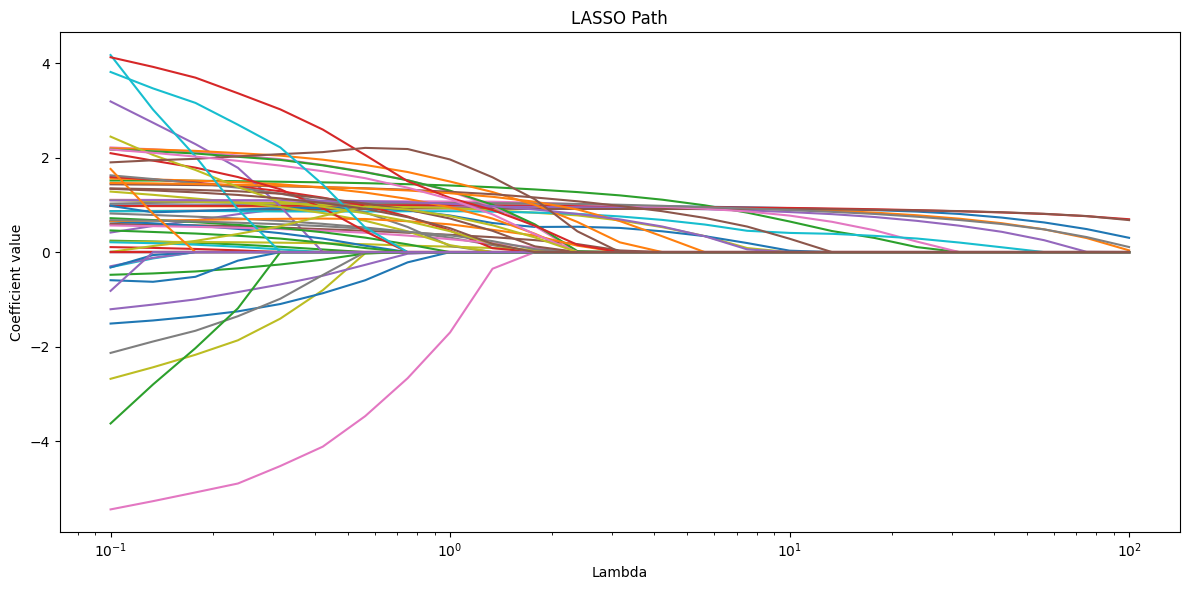

In [104]:
lasso_results.plot_lambda_path()

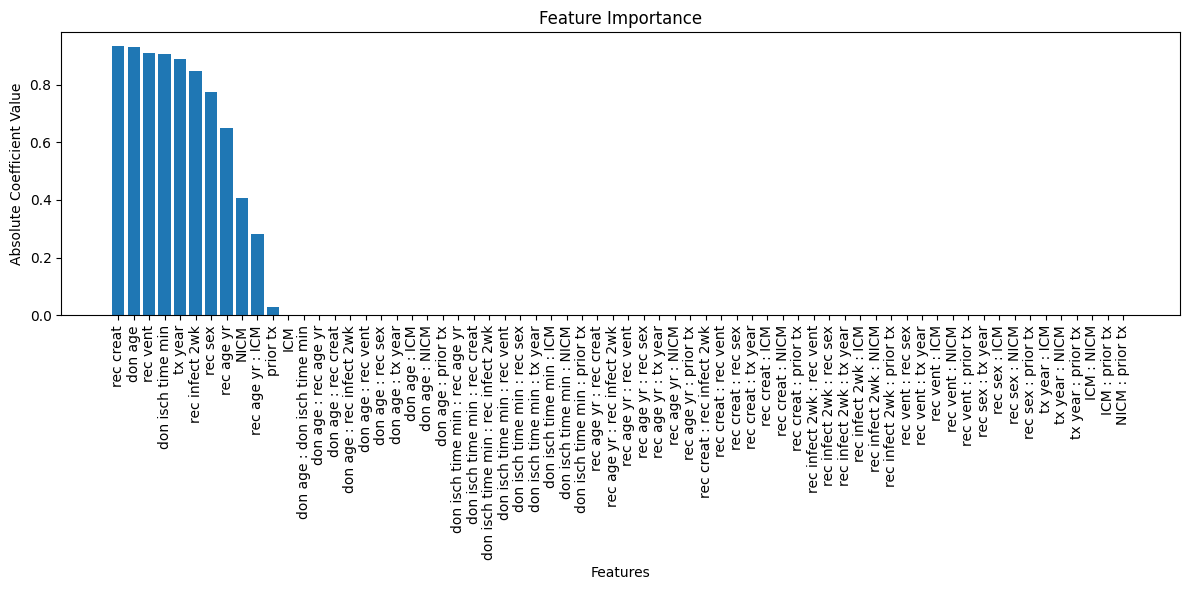

In [105]:
lasso_results.select_lambda(8)
lasso_results.plot_feature_importance()

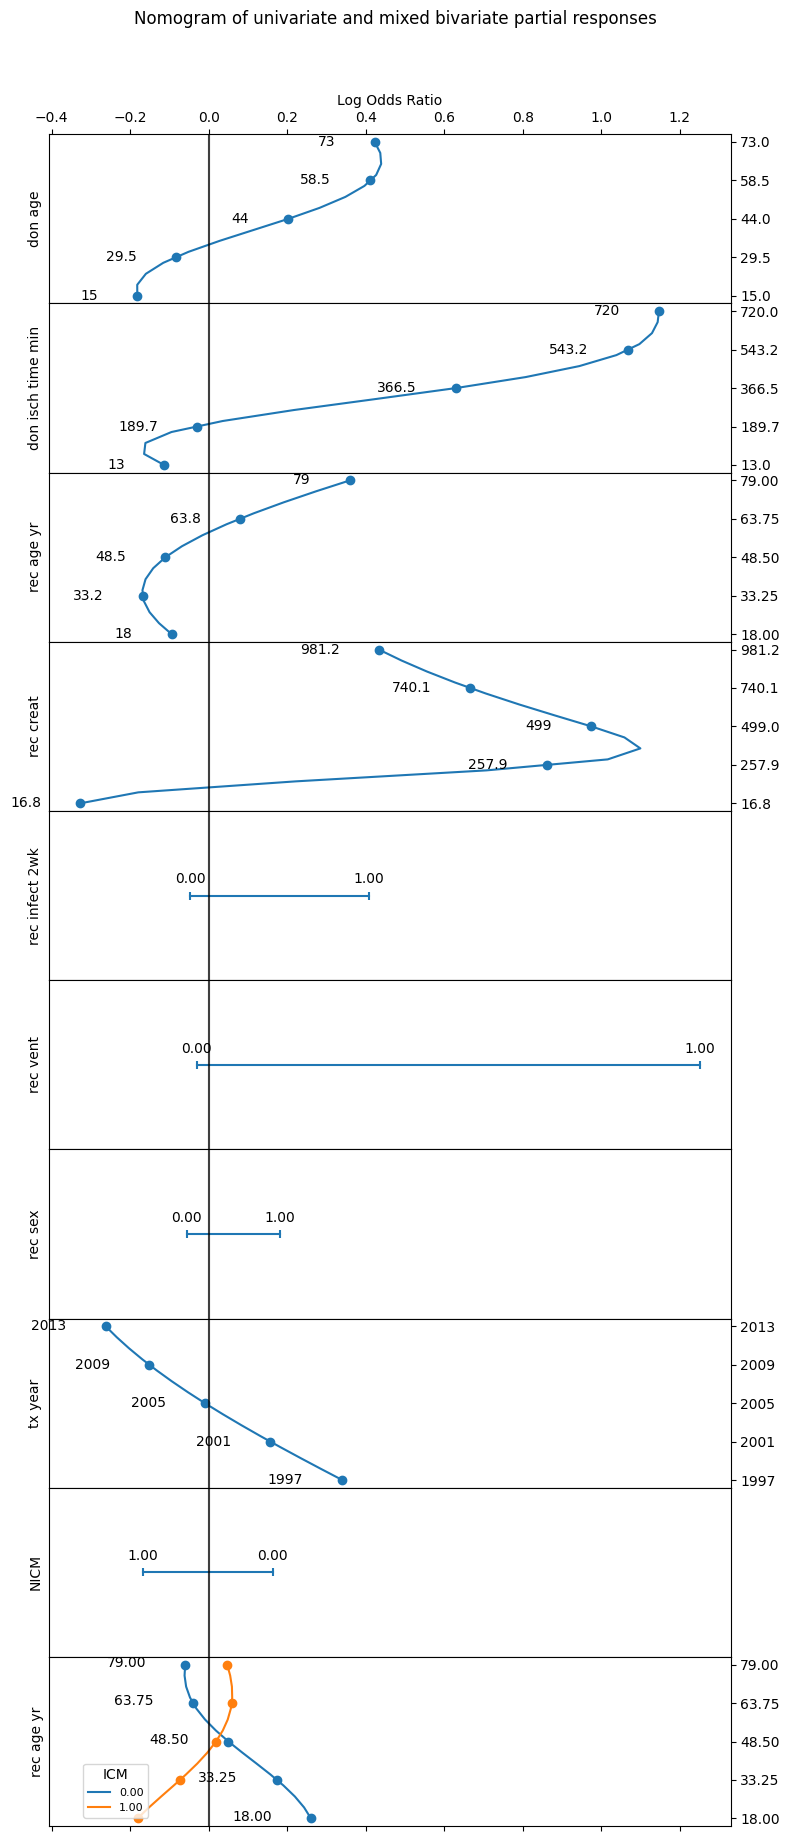

In [106]:
%reload_ext autoreload
# Note: The prPlots function is not yet available in the new implementation.
# We'll use the new nomogram function instead.
nomogram_results = nomogram(
    lasso_results,
    x_train_tensor,
    x_train0.median().values,
    x_train0.std().values,
    mlp,
    n_steps=15,
    sd_scale=2,
    method=method,
    device=device,
    categorical_threshold=15,
    subtract_univariate=True
);

In [107]:
#  test with more features
lasso_results.select_lambda(24)

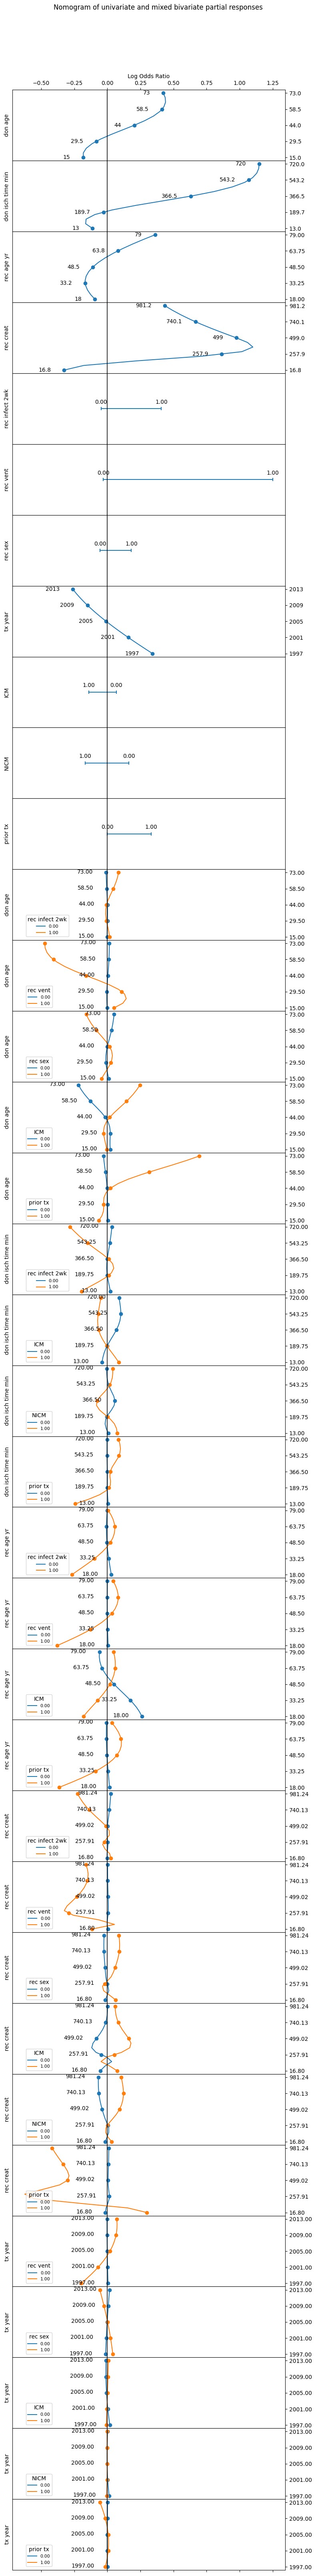

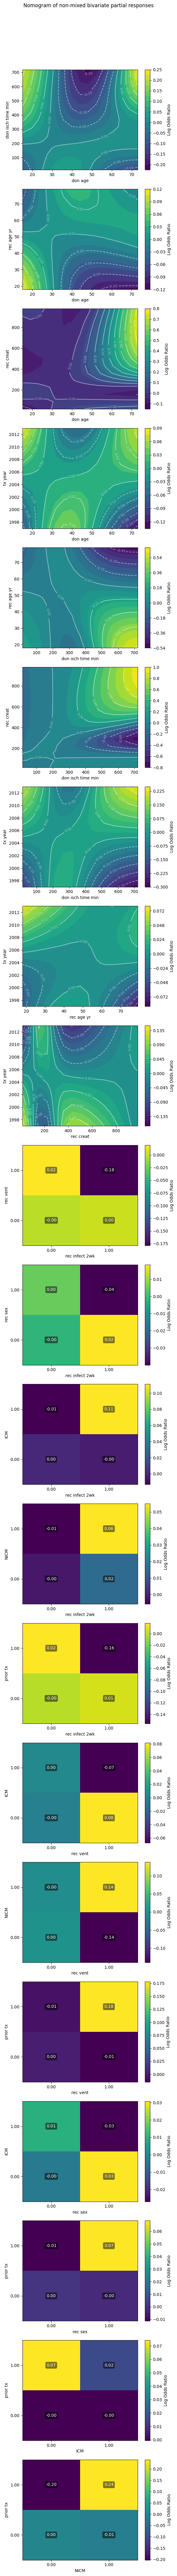

In [108]:
%reload_ext autoreload
nomogram_results = nomogram(
    lasso_results,
    x_train_tensor,
    x_train0.median().values,
    x_train0.std().values,
    mlp,
    n_steps=15,
    sd_scale=2,
    method=method,
    device=device,
    categorical_threshold=15,
    subtract_univariate=True
)

In [109]:
# return to previously selected lambda
lasso_results.select_lambda(8)

# Train the Partial Response Network

Selected features: ['don age', 'don isch time min', 'rec age yr', 'rec creat', 'rec infect 2wk', 'rec vent', 'rec sex', 'tx year', 'NICM', 'rec age yr : ICM']


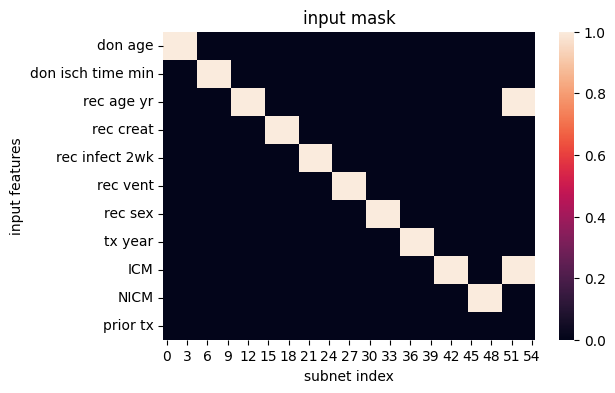

In [110]:
mask, n_features = lasso_results.get_mask()

In [111]:

prn_params = {
    'n_hidden': n_features,
    'mask': mask,
    'subnet_nodes': 5,
    'iter': 10000,
    'lr': 0.05,
    'weight_decay': 0.00001,
    'tolerance': 0.0001,
    'patience': 100,
    'device': device,
    'seed': seed
}

prn = mlpmask_pytorch(x_train, y_train, x_test, y_test, **prn_params)

Epoch 0, Training loss 0.7491950392723083, Validation loss 0.5058019161224365
Epoch 1, Training loss 0.5208706855773926, Validation loss 0.3845042884349823
Epoch 2, Training loss 0.4087001383304596, Validation loss 0.34338873624801636
Epoch 3, Training loss 0.3777749240398407, Validation loss 0.3566133379936218
Epoch 4, Training loss 0.3964877128601074, Validation loss 0.38072434067726135
Epoch 5, Training loss 0.42082345485687256, Validation loss 0.39131689071655273
Epoch 6, Training loss 0.4279251992702484, Validation loss 0.38494938611984253
Epoch 7, Training loss 0.41638854146003723, Validation loss 0.36732038855552673
Epoch 8, Training loss 0.3941255211830139, Validation loss 0.3479166626930237
Epoch 9, Training loss 0.3729674220085144, Validation loss 0.33749744296073914
Epoch 10, Training loss 0.3656228184700012, Validation loss 0.3415509760379791
Epoch 11, Training loss 0.37698015570640564, Validation loss 0.3493284583091736
Epoch 12, Training loss 0.39084920287132263, Validati

# Evaluate the Partial Response Network

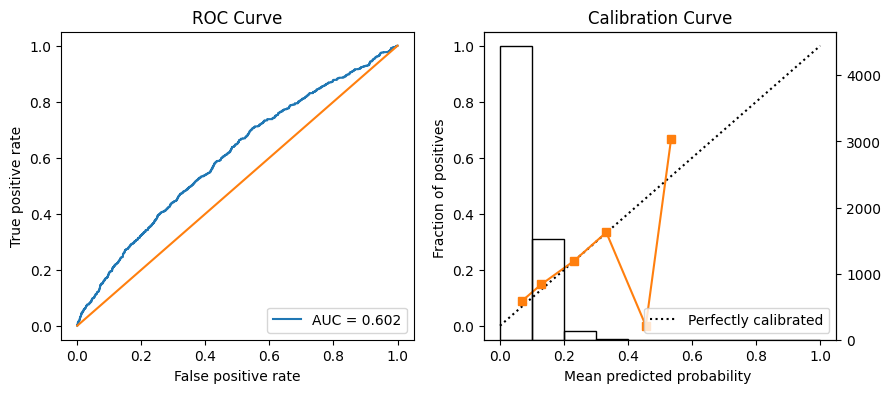


-------- Metrics --------
prevalence: 0.123
sensitivity: 0.235
specificity: 0.867
accuracy: 0.799
ppv: 0.174
auc score: 0.602
auc lower ci: 0.578
auc upper ci: 0.622
-------------------------


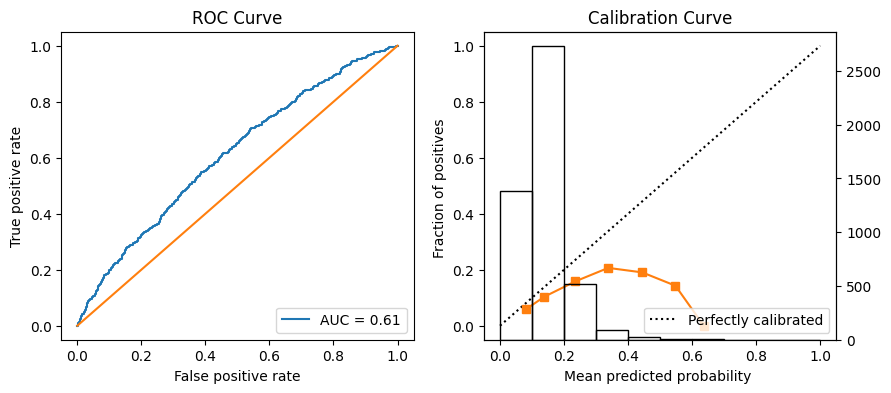


-------- Metrics --------
prevalence: 0.123
sensitivity: 0.639
specificity: 0.512
accuracy: 0.524
ppv: 0.126
auc score: 0.61
auc lower ci: 0.583
auc upper ci: 0.632
-------------------------


{'prevalence': 0.123,
 'sensitivity': 0.639,
 'specificity': 0.512,
 'accuracy': 0.524,
 'ppv': 0.126,
 'auc score': 0.61,
 'auc lower ci': '0.583',
 'auc upper ci': '0.632'}

In [112]:
y_test_prn_pytorch = prn.predict(x_test_tensor, device=device).cpu().numpy()
y_val_prn_pytorch = prn.predict(x_val_tensor, device=device).cpu().numpy()

prn_metrics_test = modelStats(y_test_prn_pytorch, y_test, y_train, auc_ci=True)
modelStats(y_val_prn_pytorch, y_val, y_train, auc_ci=True)

# LASSO on the Partial Response Network

In [113]:
# Check current device memory usage
print_tensor_info()

Tensors currently in memory:
Name: Unknown, Type: NestedTensor, Size: torch.Size([1, j0, 3]), Device: meta, Dtype: torch.float32
Name: Unknown, Type: Tensor, Size: torch.Size([3, 3]), Device: meta, Dtype: torch.float32
Name: Unknown, Type: Tensor, Size: torch.Size([2]), Device: meta, Dtype: torch.int64
Name: partial_responses_val_prn, Type: Tensor, Size: torch.Size([4750, 66]), Device: cpu, Dtype: torch.float32
Name: partial_responses_train_prn, Type: Tensor, Size: torch.Size([31315, 66]), Device: cpu, Dtype: torch.float32
Name: partial_responses_test_prn, Type: Tensor, Size: torch.Size([6120, 66]), Device: cpu, Dtype: torch.float32
Name: Unknown, Type: Tensor, Size: torch.Size([31315, 11]), Device: cuda:0, Dtype: torch.float32
Name: Unknown, Type: Tensor, Size: torch.Size([10, 11]), Device: cuda:0, Dtype: torch.float32
Name: Unknown, Type: Tensor, Size: torch.Size([10]), Device: cuda:0, Dtype: torch.float32
Name: Unknown, Type: Tensor, Size: torch.Size([1, 10]), Device: cuda:0, Dtype:

c:\Users\localuser\PRiSM\prism_github\venv_prism\Lib\site-packages\torch\distributed\distributed_c10d.py:366: UserWarning: torch.distributed.reduce_op is deprecated, please use torch.distributed.ReduceOp instead
  warnings.warn(


In [114]:
# Lowering batch size from to 256 to accomodate larger PRN model compared to the MLP
# by default, max_workers (threads) = logical CPU cores - 1. Otherwise, set optional argument max_workers
# for single GPU (cuda): choose max_workers=1.
# for MPS (Apple Silicon): start with max_workers=1, then experiment with more
partial_responses_params_prn = {
    'x_train' : x_train_tensor,
    'method' : method,
    'device' : device,
    'batch_size' : 256,
    'max_workers' : 1
}

partial_responses_train_prn = partial_responses(x_train_tensor, prn, **partial_responses_params_prn)

partial_responses_test_prn = partial_responses(x_test_tensor, prn,  **partial_responses_params_prn)

Main compute device: cuda
Max threads: 1
Batch size: 256
Univariate 0,	(cuda)
Univariate 1,	(cuda)
Univariate 2,	(cuda)
Univariate 3,	(cuda)
Univariate 4,	(cuda)
Univariate 5,	(cuda)
Univariate 6,	(cuda)
Univariate 7,	(cuda)
Univariate 8,	(cuda)
Univariate 9,	(cuda)
Univariate 10,	(cuda)
Bivariate 0,1,	(cuda)
Bivariate 0,2,	(cuda)
Bivariate 0,3,	(cuda)
Bivariate 0,4,	(cuda)
Bivariate 0,5,	(cuda)
Bivariate 0,6,	(cuda)
Bivariate 0,7,	(cuda)
Bivariate 0,8,	(cuda)
Bivariate 0,9,	(cuda)
Bivariate 0,10,	(cuda)
Bivariate 1,2,	(cuda)
Bivariate 1,3,	(cuda)
Bivariate 1,4,	(cuda)
Bivariate 1,5,	(cuda)
Bivariate 1,6,	(cuda)
Bivariate 1,7,	(cuda)
Bivariate 1,8,	(cuda)
Bivariate 1,9,	(cuda)
Bivariate 1,10,	(cuda)
Bivariate 2,3,	(cuda)
Bivariate 2,4,	(cuda)
Bivariate 2,5,	(cuda)
Bivariate 2,6,	(cuda)
Bivariate 2,7,	(cuda)
Bivariate 2,8,	(cuda)
Bivariate 2,9,	(cuda)
Bivariate 2,10,	(cuda)
Bivariate 3,4,	(cuda)
Bivariate 3,5,	(cuda)
Bivariate 3,6,	(cuda)
Bivariate 3,7,	(cuda)
Bivariate 3,8,	(cuda)
Biva

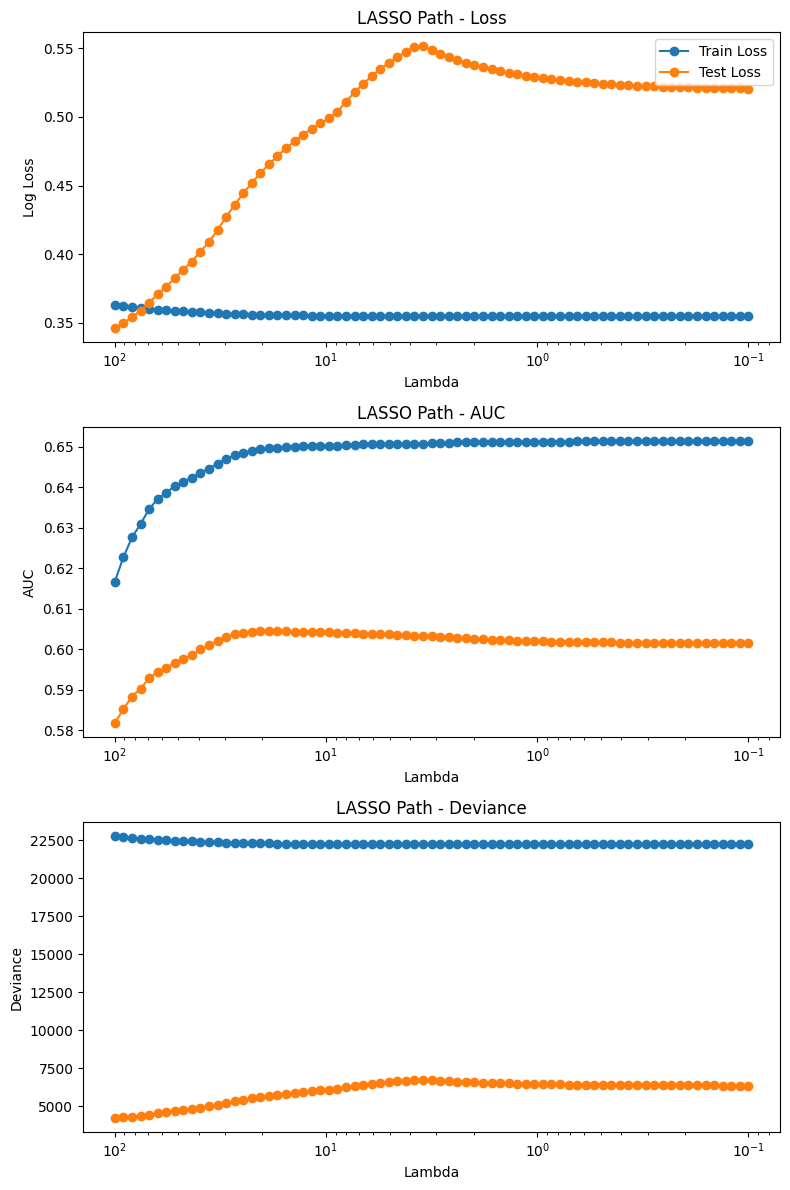

All fits converged successfully.


In [115]:
%reload_ext autoreload
lasso_results_prn = lasso(
    partial_responses_train_prn, 
    partial_responses_test_prn, 
    y_train, 
    y_test, 
    feature_names=feature_names,
    nlambda=75, 
    min_lambda=0.1,
    max_lambda=100,
    batch_size=2,
    seed=seed
)

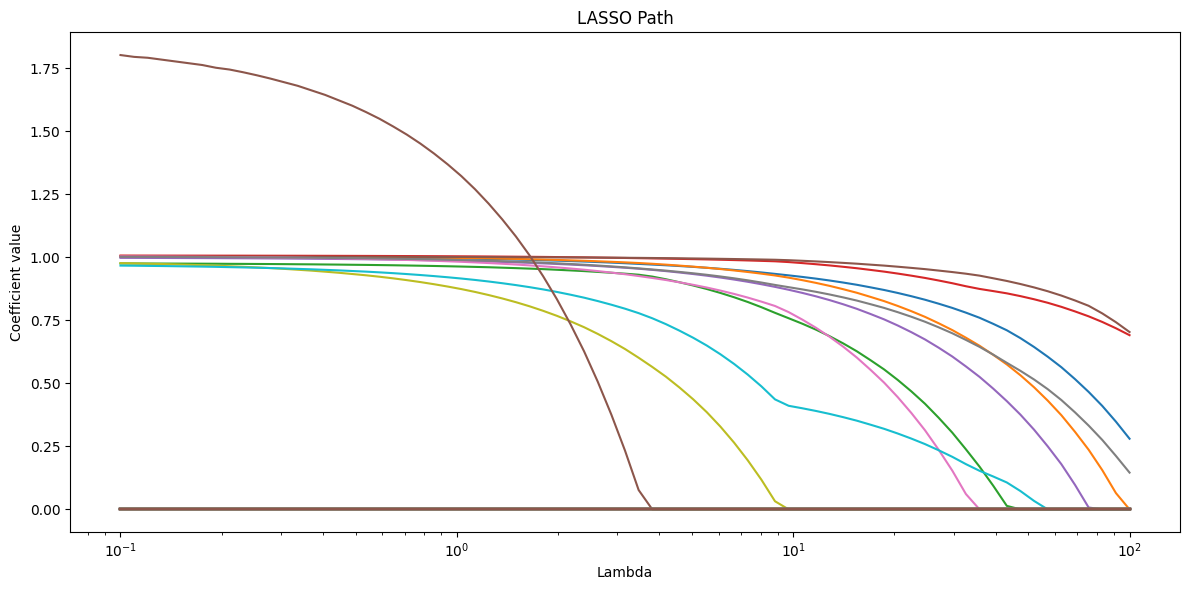

In [116]:
lasso_results_prn.plot_lambda_path()

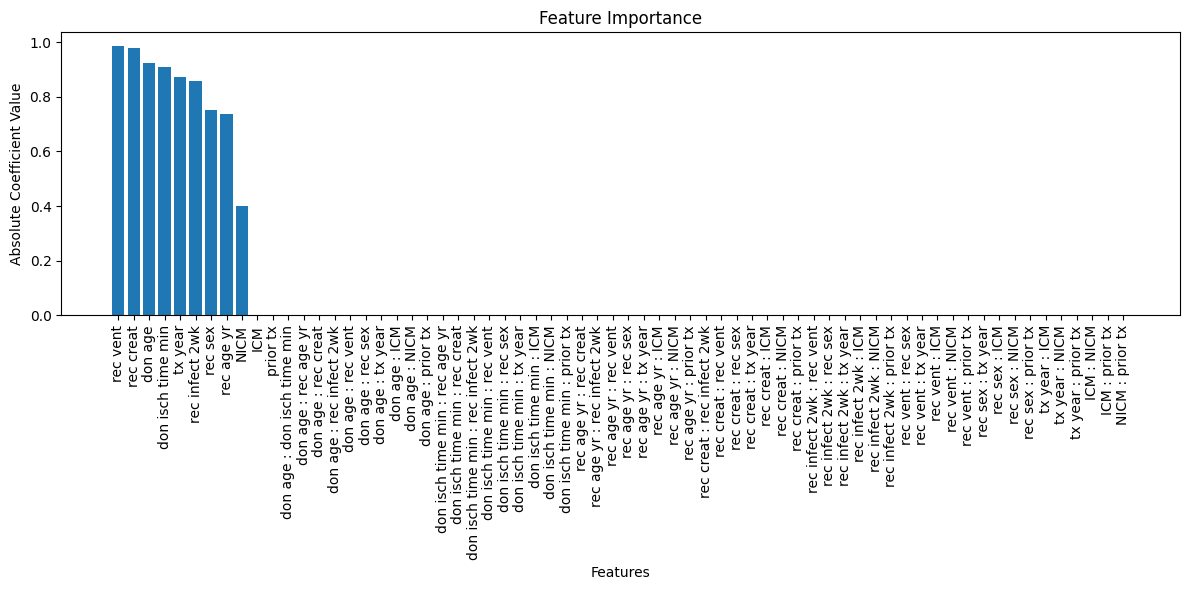

In [117]:
lasso_results_prn.select_lambda(24)
lasso_results_prn.plot_feature_importance()

# Validation inference

In [118]:
prn_lasso = lasso_results_prn.get_selected_model()

In [119]:
partial_responses_params_prn = {
    'x_train' : x_train_tensor,
    'method' : method,
    'device' : device,
    'batch_size' : 256,
    'max_workers' : 1
}

partial_responses_val_prn = partial_responses(x_val_tensor, prn, **partial_responses_params_prn)

Main compute device: cuda
Max threads: 1
Batch size: 256
Univariate 0,	(cuda)
Univariate 1,	(cuda)
Univariate 2,	(cuda)
Univariate 3,	(cuda)
Univariate 4,	(cuda)
Univariate 5,	(cuda)
Univariate 6,	(cuda)
Univariate 7,	(cuda)
Univariate 8,	(cuda)
Univariate 9,	(cuda)
Univariate 10,	(cuda)
Bivariate 0,1,	(cuda)
Bivariate 0,2,	(cuda)
Bivariate 0,3,	(cuda)
Bivariate 0,4,	(cuda)
Bivariate 0,5,	(cuda)
Bivariate 0,6,	(cuda)
Bivariate 0,7,	(cuda)
Bivariate 0,8,	(cuda)
Bivariate 0,9,	(cuda)
Bivariate 0,10,	(cuda)
Bivariate 1,2,	(cuda)
Bivariate 1,3,	(cuda)
Bivariate 1,4,	(cuda)
Bivariate 1,5,	(cuda)
Bivariate 1,6,	(cuda)
Bivariate 1,7,	(cuda)
Bivariate 1,8,	(cuda)
Bivariate 1,9,	(cuda)
Bivariate 1,10,	(cuda)
Bivariate 2,3,	(cuda)
Bivariate 2,4,	(cuda)
Bivariate 2,5,	(cuda)
Bivariate 2,6,	(cuda)
Bivariate 2,7,	(cuda)
Bivariate 2,8,	(cuda)
Bivariate 2,9,	(cuda)
Bivariate 2,10,	(cuda)
Bivariate 3,4,	(cuda)
Bivariate 3,5,	(cuda)
Bivariate 3,6,	(cuda)
Bivariate 3,7,	(cuda)
Bivariate 3,8,	(cuda)
Biva

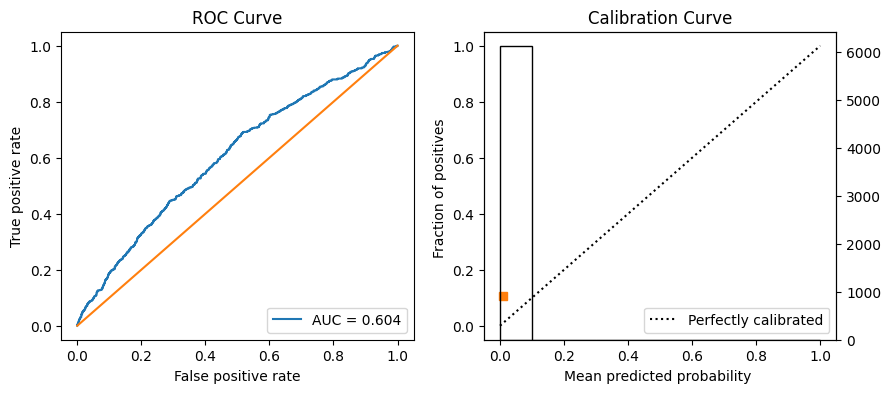


-------- Metrics --------
prevalence: 0.123
sensitivity: 0.0
specificity: 1.0
accuracy: 0.893
ppv: nan
auc score: 0.604
auc lower ci: 0.579
auc upper ci: 0.626
-------------------------


C:\Users\localuser\PRiSM\prism_github\prism\legacy.py:181: RuntimeWarning: invalid value encountered in scalar divide
  ppv = tp/(tp+fp);


In [120]:
y_pred_test_prn_lasso = prn_lasso.predict_proba(partial_responses_test_prn.cpu().numpy())[:, 1]
y_pred_val_prn_lasso = prn_lasso.predict_proba(partial_responses_val_prn.cpu().numpy())[:, 1]
lasso_metrics_test = modelStats(y_pred_test_prn_lasso, y_test, y_train, auc_ci=True)

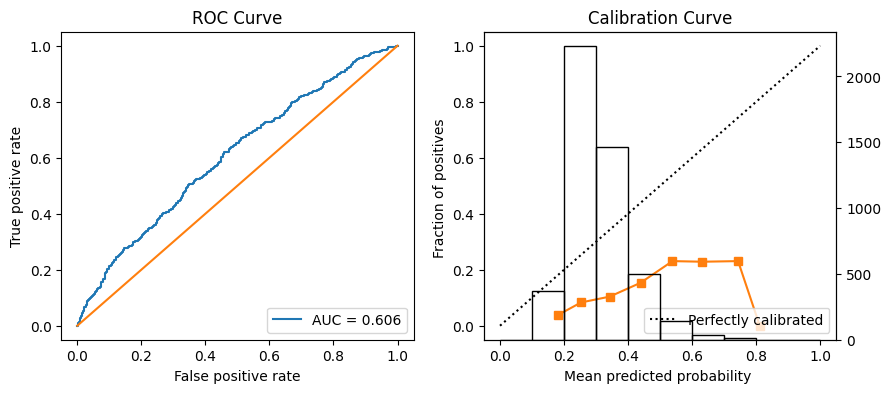


-------- Metrics --------
prevalence: 0.123
sensitivity: 1.0
specificity: 0.0
accuracy: 0.099
ppv: 0.099
auc score: 0.606
auc lower ci: 0.582
auc upper ci: 0.627
-------------------------


{'prevalence': 0.123,
 'sensitivity': 1.0,
 'specificity': 0.0,
 'accuracy': 0.099,
 'ppv': 0.099,
 'auc score': 0.606,
 'auc lower ci': '0.582',
 'auc upper ci': '0.627'}

In [121]:
modelStats(y_pred_val_prn_lasso, y_val, y_train, auc_ci=True)

# Partial Response Network Nomogram

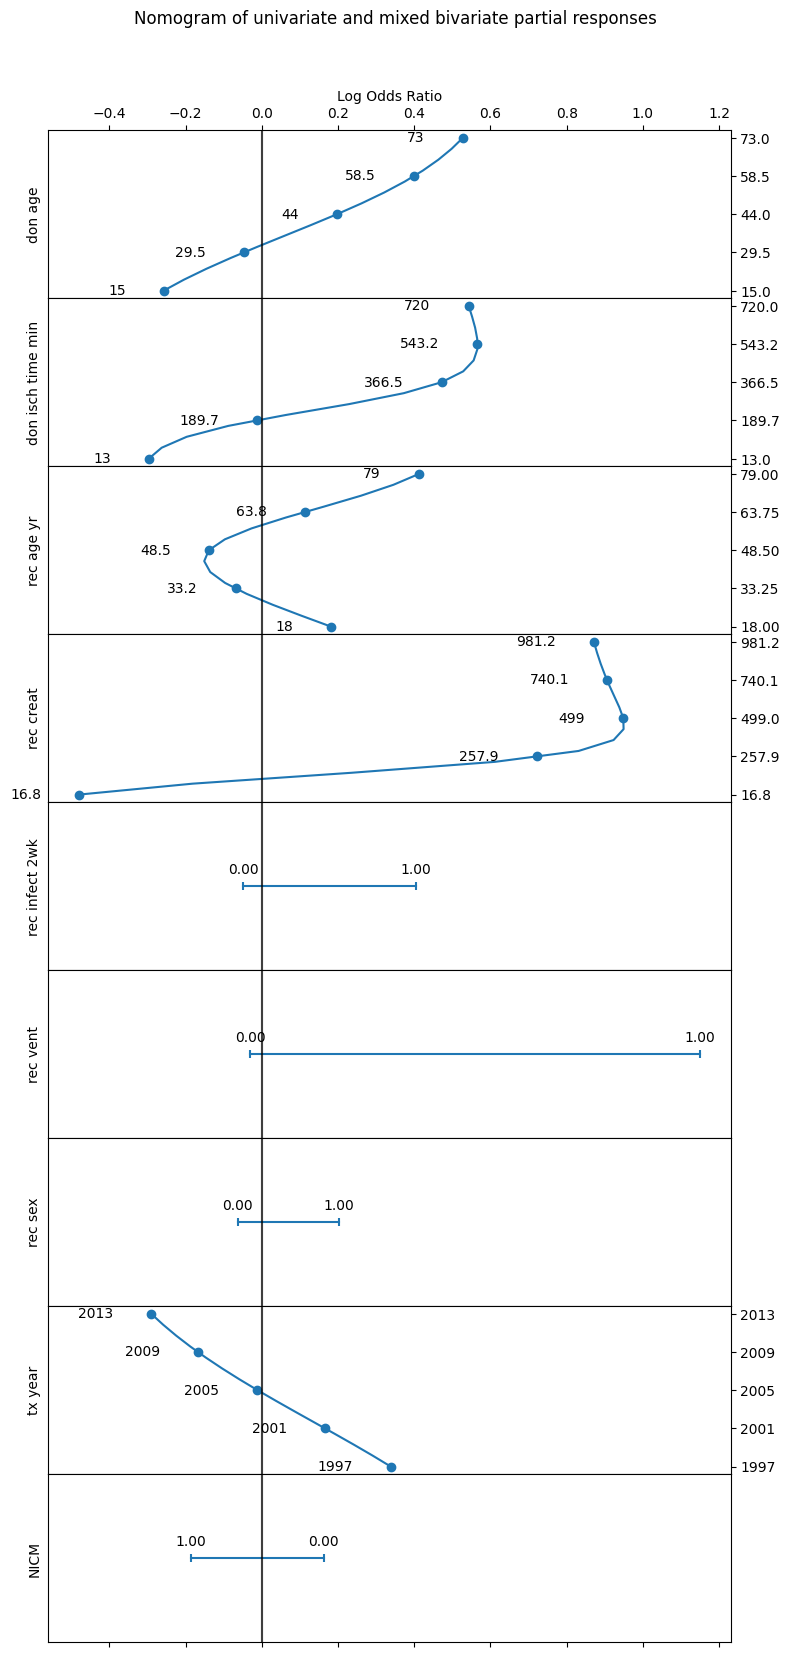

In [122]:
nomogram(
    lasso_results_prn,
    x_train_tensor,
    x_train0.median().values,
    x_train0.std().values,
    prn,
    n_steps=15,
    sd_scale=2,
    method=method,
    device=device,
    categorical_threshold=15,
    subtract_univariate=True
);

## Nomogram with more 

TODO: modify lasso_results to include possibility to select all features, all univariate, all bivariate (e.g. for plotting).

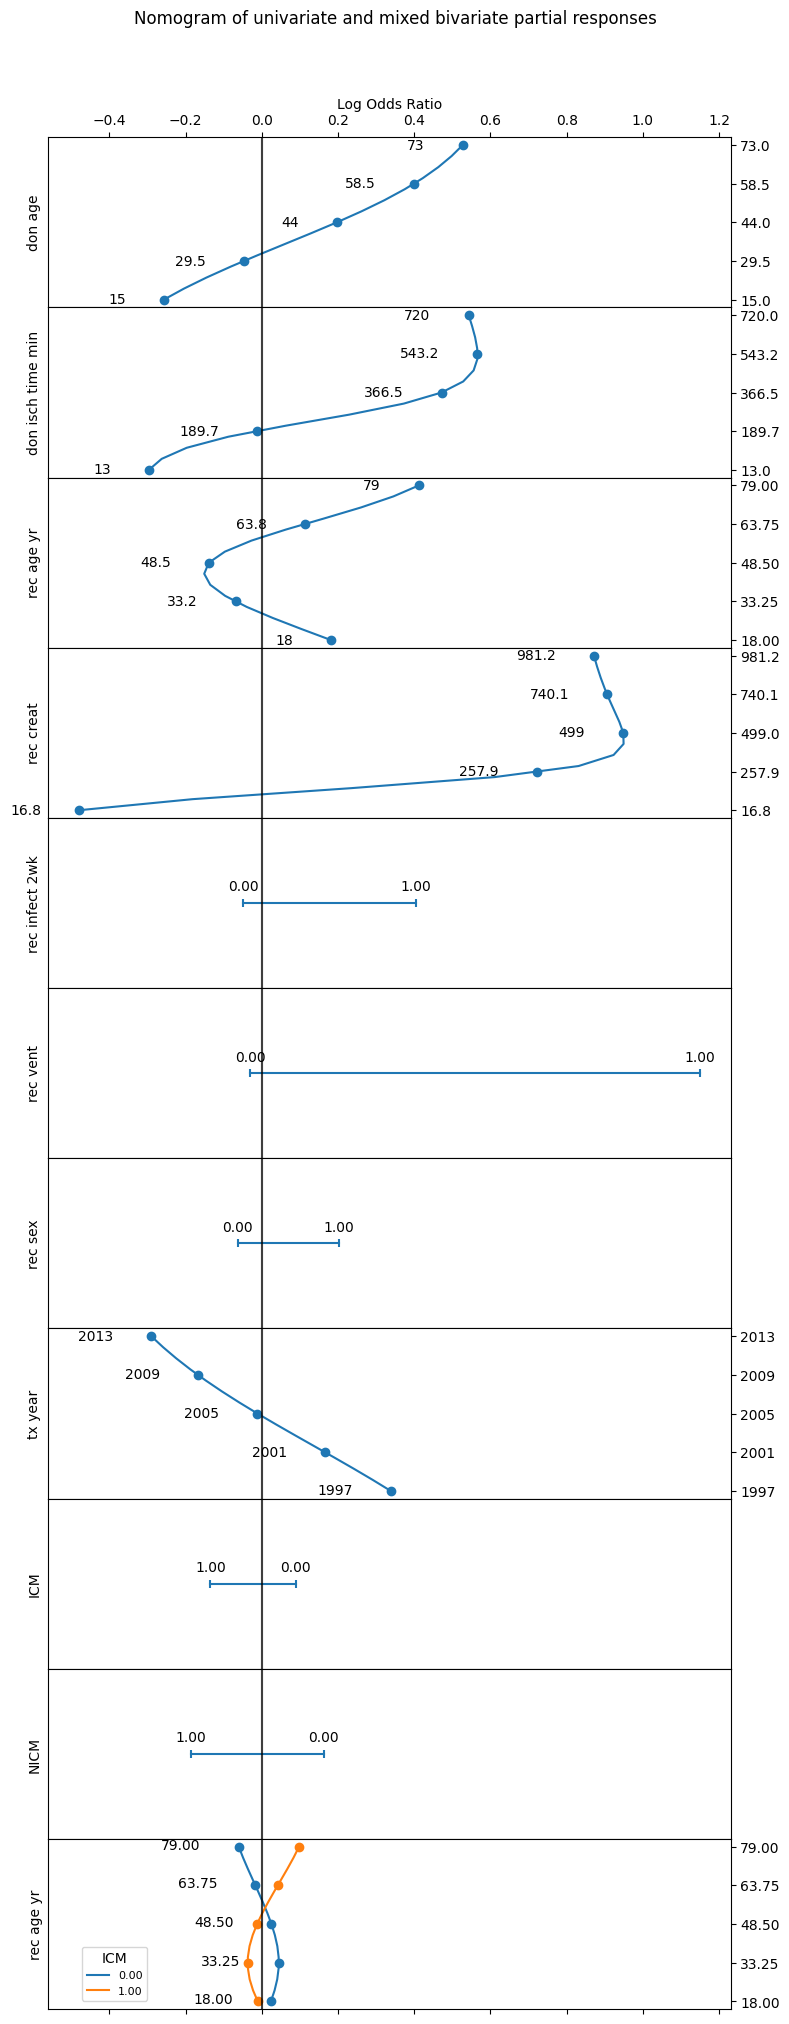

In [123]:
# test with more features
# todo add all features method to lasso_results object.
lasso_results_prn.select_lambda(74)
nomogram(
    lasso_results_prn,
    x_train_tensor,
    x_train0.median().values,
    x_train0.std().values,
    prn,
    n_steps=15,
    sd_scale=2,
    method=method,
    device=device,
    categorical_threshold=15
);